In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
from pathlib import Path
import os
import pandas as pd
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import json
from scipy.signal import find_peaks


from utils import create_uniform_energy_grid, shift_test_batch, normalize_spectra_by_area
from models import MultiClassifierV2_STN, CVAE


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Optionally, you can print more details about the GPU if available
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs available: {torch.cuda.device_count()}")

/home/issa/new_project_clone/GenXPS_public/genXPS/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU Name: Tesla T4
Number of GPUs available: 1


In [3]:

start_energy = 40
end_energy = 700
BE_values = create_uniform_energy_grid(start_energy, end_energy)

In [4]:
import torch

# Load the entire dictionary object
test_data = torch.load('../data/synthetic_data_hard_final/test_data.pt')

# Access each item by its key
X_test = test_data['features']
y_test = test_data['labels']


# Now you can use these tensors for evaluation
print(f"Loaded features shape: {X_test.shape}")
print(f"Loaded labels shape: {y_test.shape}")


Loaded features shape: torch.Size([20000, 6601])
Loaded labels shape: torch.Size([20000, 40])


In [5]:

# 4. Create an instance of the model and send it to target device
classifier = MultiClassifierV2_STN().to(device)

# Load the saved model
model_path = Path("../../../local_models/STN_3_shift.pth")


classifier.load_state_dict(torch.load(model_path))
classifier.eval()

cvae_path = Path("/home/issa/new_project_clone/local_models/CVAE1d(alkane).pth")
latent_dim = 1
input_dim = 6601
cond_dim = 40

# Initialize model
CVAE = CVAE(input_dim, latent_dim, cond_dim).to(device)
# Load the trained model
CVAE.load_state_dict(torch.load(cvae_path))
CVAE.eval()  # Set the model to evaluation mode

CVAE(
  (encoder_layers): Sequential(
    (0): Linear(in_features=6641, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): Dropout(p=0.3, inplace=False)
    (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (6): LeakyReLU(negative_slope=0.2)
  )
  (fc_mu_logvar): Linear(in_features=256, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=41, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (6): LeakyReLU(negative_slope=0.2)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=1024, out_features=512, bias=True)

--- Prediction Summary for Sample #5 ---
 Functional Group  Actual  Predicted
ester (aliphatic)     1.0        1.0
    chlorobenzene     1.0        1.0
           alkane     1.0        1.0
---------------------------------------------

Found 3 positive predictions. Attempting Explanation.
Peak indices: [1606 1622 2449 2490 2502 2504 2506 2516 2521 4922 4936]
Peak heights: [0.00684578 0.00363239 0.03487655 0.00508489 0.00067481 0.00062374
 0.0007946  0.00120183 0.00091409 0.01068577 0.0105634 ]


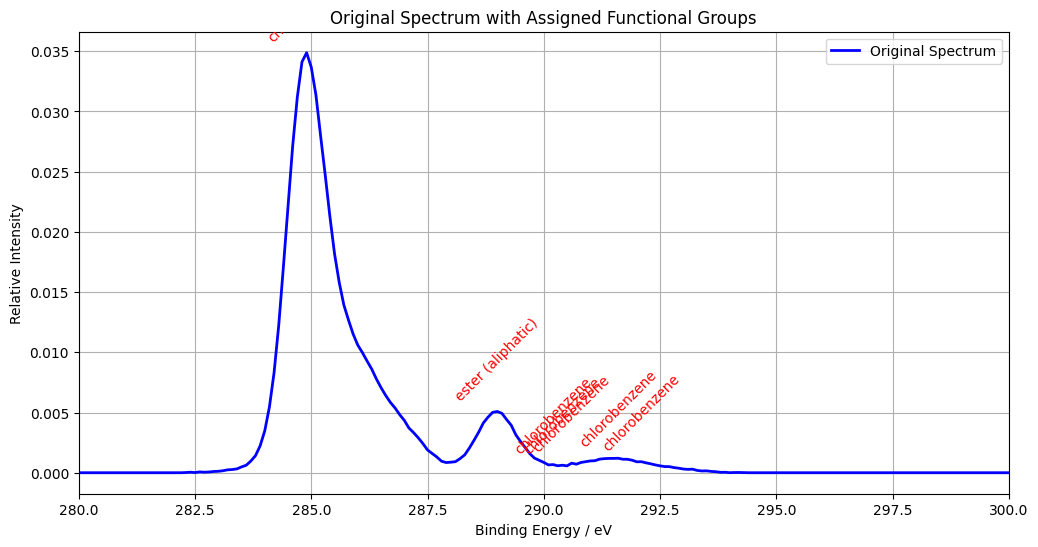

In [51]:

# --- 1. Setup & Data Preparation ---
# Assume FG_list, model_0, X_test, y_test, BE_values, and device are defined

# Select a single spectrum and its true label
SAMPLE_INDEX = 5
input_spectrum = X_test[SAMPLE_INDEX].unsqueeze(0).to(device)
true_labels = y_test[SAMPLE_INDEX].to(device)
input_spectrum.requires_grad = True

# --- 2. Get Model Predictions for the Input Spectrum ---
with torch.inference_mode():
    logits, _ = classifier(input_spectrum)
    predictions = torch.round(torch.sigmoid(logits)).squeeze()


# --- Create and Display a Prediction Summary DataFrame ---
true_labels_np = true_labels.cpu().numpy()
predictions_np = predictions.cpu().numpy()

with open("FG_list.json", "r") as f:
    FG_list= json.load(f)


df = pd.DataFrame({
    'Functional Group': FG_list,
    'Actual': true_labels_np,
    'Predicted': predictions_np
})

summary_df = df[(df['Actual'] == 1) | (df['Predicted'] == 1)]

print("--- Prediction Summary for Sample #{} ---".format(SAMPLE_INDEX))
print(summary_df.to_string(index=False))
print("-" * 45)
# ----------------------------------------------------------------

# --- 3. Compute and Plot Attributions for Each Positive Class ---
positive_class_indices = torch.where(predictions == 1)[0]

if len(positive_class_indices) == 0:
    print("\nNo positive classes were predicted for this spectrum.")
else:
    print(f"\nFound {len(positive_class_indices)} positive predictions. Attempting Explanation.")


# Base normalized label
plain_label = predictions_np / len(positive_class_indices)
plain_label_tensor = torch.tensor(plain_label, dtype=torch.float32).to(device)

# Generate a latent vector for decoding
z = torch.randn(1, latent_dim).to(device)

# Store generated spectra for each leave-one-out FG
generated_spectra_dict = {}

for fg_idx in positive_class_indices:
    # Copy the plain label
    label_loo = plain_label_tensor.clone()

    # Set the current FG to zero
    label_loo[fg_idx] = 0

    # Renormalize so the remaining positive FGs sum to 1
    if label_loo.sum() > 0:
        label_loo = label_loo / label_loo.sum()
    
    # Add batch dimension
    y_example = label_loo.unsqueeze(0)  # [1, cond_dim]

    # Generate spectrum
    with torch.no_grad():
        spectrum = CVAE.decode(z, y_example)

    # Move to CPU and clean negative values
    spectrum = spectrum.cpu().squeeze()
    spectrum[spectrum < 0] = 0

    # Store the spectrum
    generated_spectra_dict[fg_idx] = spectrum

    '''
    plt.figure(figsize=(10, 4))
    plt.plot(BE_values, normalize_spectra_by_area(spectrum), color="red", alpha=0.7)
    plt.title(f"Generated spectrum with FG index {FG_list[fg_idx]} zeroed")
    plt.xlabel("BE / eV")
    plt.ylabel("Relative intensity")
    plt.grid(True)
    plt.show()
    '''

# input_spectrum: 1D tensor or NumPy array
input_spectrum_np = input_spectrum.detach().cpu().squeeze().numpy()

# Find peaks
peaks, properties = find_peaks(input_spectrum_np, height=0.0005)  # height=threshold to avoid noise

print("Peak indices:", peaks)
print("Peak heights:", properties['peak_heights'])

# Store assignments: peak index -> FG index that caused it to disappear
peak_assignments = {}

for peak_idx in peaks:
    # Track the FG that most reduces this peak
    min_value = np.inf
    assigned_fg = None
    
    for fg_idx, spectrum in generated_spectra_dict.items():
        value_at_peak = spectrum[peak_idx].item()  # scalar
        if value_at_peak < min_value:
            min_value = value_at_peak
            assigned_fg = fg_idx
    
    peak_assignments[peak_idx] = assigned_fg


# input_spectrum: original spectrum tensor
X_example = input_spectrum.detach().cpu().squeeze().numpy()

# Convert BE_values to numpy
BE_values_np = np.array(BE_values)

# Plot original spectrum
plt.figure(figsize=(12, 6))
plt.plot(BE_values_np, X_example, color="blue", linewidth=2, label="Original Spectrum")

# Annotate each peak with the corresponding FG name
for peak_idx, fg_idx in peak_assignments.items():
    fg_name = FG_list[fg_idx]  # Map index to name
    peak_energy = BE_values_np[peak_idx]
    peak_height = X_example[peak_idx]

    # Add text annotation slightly above the peak
    plt.text(peak_energy, peak_height + 0.02*X_example.max(), fg_name,
             rotation=45, ha='center', va='bottom', fontsize=10, color='red', clip_on=True)

# Labels and styling
plt.title("Original Spectrum with Assigned Functional Groups")
plt.xlim(280,300)
plt.xlabel("Binding Energy / eV")
plt.ylabel("Relative Intensity")
plt.grid(True)
plt.legend()
plt.show()